In [1]:
import pandas as pd
df=pd.read_csv("predictive_maintenance.csv")
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [3]:
df['Target'].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [6]:
df['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

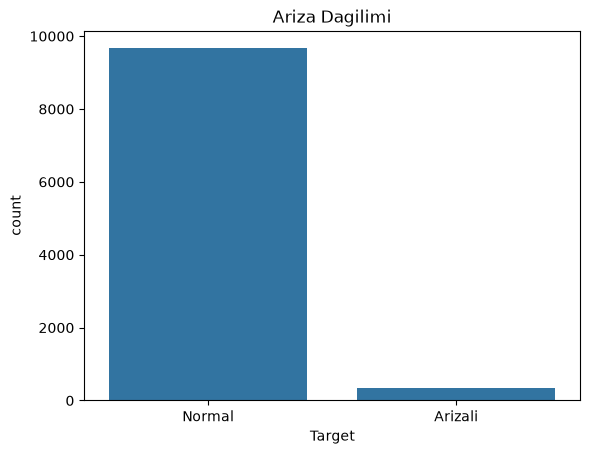

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Target', data=df)
plt.title('Ariza Dagilimi')
plt.xticks([0,1],('Normal','Arizali'))
plt.show()

In [11]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


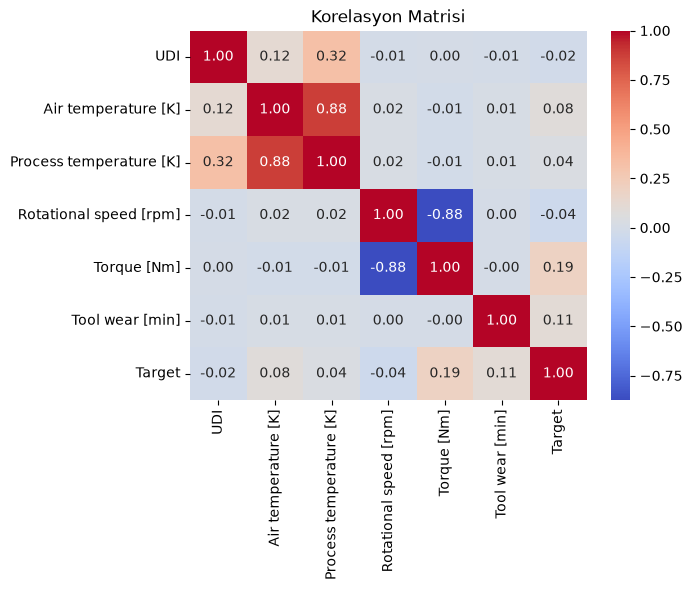

In [12]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,fmt='.2f', cmap='coolwarm')
plt.title('Korelasyon Matrisi')
plt.show()

In [15]:
df=df.drop(columns=['UDI','Product ID','Failure Type'])
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [17]:
df['Type']=df['Type'].map({'L':0,'M':1,'H':2})
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0


In [ ]:
X=df.drop(columns=['Target'])
Y=df['Target']


In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y, test_size=0.2,random_state=42)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(8000, 6)
(8000,)
(2000, 6)
(2000,)


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_lr=LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)
model_lr.fit(X_train,Y_train)
Y_predict_lr=model_lr.predict(X_test)
print(classification_report(Y_test,Y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1939
           1       0.13      0.84      0.22        61

    accuracy                           0.82      2000
   macro avg       0.56      0.83      0.56      2000
weighted avg       0.97      0.82      0.88      2000



In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model_rf=RandomForestClassifier(class_weight='balanced',random_state=42)
model_rf.fit(X_train,Y_train)
Y_predict_rf=model_rf.predict(X_test)
print(classification_report(Y_test,Y_predict_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.64      0.67      0.66        61

    accuracy                           0.98      2000
   macro avg       0.82      0.83      0.82      2000
weighted avg       0.98      0.98      0.98      2000



In [40]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0


In [38]:
X_train.columns = ['Type', 'Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear']
X_test.columns = ['Type', 'Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear']

In [49]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(scale_pos_weight=9661/339, random_state=42)
model_xgb.fit(X_train, Y_train)
Y_predict_xgb = model_xgb.predict(X_test)
print(classification_report(Y_test, Y_predict_xgb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.65      0.69      0.67        61

    accuracy                           0.98      2000
   macro avg       0.82      0.84      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [52]:
from sklearn.metrics import f1_score

print("Logistic Regression\n")
print("Train F1:", f1_score(Y_train, model_lr.predict(X_train)))
print("Test F1:", f1_score(Y_test, Y_predict_lr))

print("\nRandom Forest\n")
print("Train F1:", f1_score(Y_train, model_rf.predict(X_train)))
print("Test F1:", f1_score(Y_test, Y_predict_rf))

print("\nXGBoost")
print("Train F1:", f1_score(Y_train, model_xgb.predict(X_train)))
print("Test F1:", f1_score(Y_test, Y_predict_xgb))

Logistic Regression

Train F1: 0.23616236162361623
Test F1: 0.22174840085287847

Random Forest

Train F1: 0.9946332737030411
Test F1: 0.656

XGBoost
Train F1: 0.9982046678635548
Test F1: 0.6666666666666666


In [43]:
print(X_train.columns)

Index(['Type', 'Air_temperature', 'Process_temperature', 'Rotational_speed',
       'Torque', 'Tool_wear'],
      dtype='str')
